<a href="https://colab.research.google.com/github/TheRabbit010/From-Colab/blob/main/Copy_of_Datapag_extract_with_graph_ver_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

upload file ( should be first cell )

In [1]:
# ==========================================================
# CELL 1: FILE UPLOADER (RUN ONCE)
# ==========================================================
import os
from google.colab import files

try:
    import olefile
except ImportError:
    !pip install -q olefile
    import olefile

print("==========================================================")
print(" CELL 1: FILE UPLOADER")
print("==========================================================\n")

uploaded = files.upload()

# Filter specifically for .paq files
paq_files = [f for f in uploaded.keys() if f.lower().endswith('.paq')]

if paq_files:
    paq_file = paq_files[0]
    print(f"\n✓ Success! Datapaq file '{paq_file}' stored in memory.")
    print("👉 You can now run Cell 2.")
else:
    uploaded_names = list(uploaded.keys())
    print(f"\n❌ Error: No '.paq' file found. You uploaded: {uploaded_names}")
    print("👉 Please re-run Cell 1 and upload your binary .paq file (not the .ipynb notebook).")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.6/114.6 kB 4.8 MB/s eta 0:00:00
 CELL 1: FILE UPLOADER



Saving WK39 M2 K2_22092026,Con L,Sp1270,g0_NewBarL_2.paq to WK39 M2 K2_22092026,Con L,Sp1270,g0_NewBarL_2.paq

✓ Success! Datapaq file 'WK39 M2 K2_22092026,Con L,Sp1270,g0_NewBarL_2.paq' stored in memory.
👉 You can now run Cell 2.


memory clear for new image

In [2]:
# --- CLEAR PREVIOUS FILE MEMORY ---
embedded_img = None
operator_comment = "N/A"
process_settings = "N/A"
metadata_dict = {}

Cell 2: Run Main Extraction & Processing , ignore noise spikes and find the true oven entrance

In [3]:
# ==========================================================
# CELL 2: MAIN PROCESSOR & EXTRACTION
# ==========================================================
import os, zlib, struct, io, re
import numpy as np
import pandas as pd
from PIL import Image

pd.options.display.float_format = '{:.1f}'.format

print("==========================================================")
print(" CELL 2: MAIN PROCESSOR")
print("==========================================================\n")

# ------------------------------------------------------------------------------
# 🚨 RESET PREVIOUS FILE MEMORY BEFORE PROCESSING NEW FILE
# ------------------------------------------------------------------------------
embedded_img = None
operator_comment = "N/A"
process_settings = "N/A"
metadata_dict = {}
if 'df_master' in globals():
    del df_master

LINE_SPEED_MPM = 1.2700  # 1.27 meters per minute

if 'paq_file' not in globals() or not os.path.exists(paq_file):
    print("❌ Error: No file found in memory. Please run Cell 1 first.")
else:
    print(f"✓ Processing file: '{paq_file}'...\n")

    def decompress_stream(ole_obj, stream_name):
        try:
            raw_data = ole_obj.openstream(stream_name).read()
            zlib_data = raw_data[8:] if raw_data.startswith(b'ZLIB') else raw_data
            try:
                return zlib.decompress(zlib_data)
            except Exception:
                return zlib.decompress(zlib_data, -zlib.MAX_WBITS)
        except Exception:
            return None

    def extract_probe_series_autonomously(decomp_bytes):
        best_series = []
        for offset in range(0, min(12000, len(decomp_bytes) - 800), 1):
            rem = len(decomp_bytes) - offset
            cnt = rem // 8
            if cnt < 500: continue
            try:
                vals = struct.unpack(f"<{cnt}d", decomp_bytes[offset : offset + cnt * 8])
            except Exception:
                continue

            clean_vals, glitch_count = [], 0
            for v in vals:
                if isinstance(v, float) and -10.0 <= v <= 650.0:
                    clean_vals.append(v)
                    glitch_count = 0
                else:
                    glitch_count += 1
                    if len(clean_vals) > 500:
                        if glitch_count <= 5:
                            clean_vals.append(clean_vals[-1] if clean_vals else 0.0)
                        else: break
                    elif glitch_count > 3: clean_vals = []

            if len(clean_vals) > len(best_series) and max(clean_vals) > 150.0:
                best_series = clean_vals

        return best_series

    try:
        ole = olefile.OleFileIO(paq_file)
        probe_streams = [s for s in ole.listdir() if len(s) >= 4 and s[0] == 'Paqfiles' and s[2] == 'ProbeResults']
        probe_streams = sorted(probe_streams, key=lambda x: x[-1])

        all_probes = {}
        for stream_path in probe_streams:
            stream_name = "/".join(stream_path)
            probe_folder = stream_path[-1]
            probe_num = int(''.join(filter(str.isdigit, probe_folder))) + 1 if any(c.isdigit() for c in probe_folder) else len(all_probes) + 1
            col_name = f"PB#{probe_num}"

            d = decompress_stream(ole, stream_name)
            if d:
                series = extract_probe_series_autonomously(d)
                if series:
                    all_probes[col_name] = series
                    print(f"  ✓ {col_name}: Extracted {len(series)} raw samples")

        if all_probes:
            max_samples = max(len(v) for v in all_probes.values())
            aligned_probes = {k: (v + [np.nan] * (max_samples - len(v)) if len(v) < max_samples else v) for k, v in all_probes.items()}

            df_master = pd.DataFrame(aligned_probes)
            df_master.insert(0, "Time_Seconds", range(len(df_master)))
            df_master.insert(1, "Time_HHMMSS", pd.to_datetime(df_master["Time_Seconds"], unit='s').dt.strftime('%H:%M:%S'))

            probe_cols = [col for col in df_master.columns if col.startswith("PB#")]

            # --- INDIVIDUAL PROBE ENTRANCE DETECTION (60°C SUSTAINED FOR 15s) ---
            SUSTAINED_SECONDS = 15
            probe_start_secs = {}

            for col in probe_cols:
                is_p60 = (df_master[col] >= 60.0)
                valid_p_mask = is_p60.copy()
                for i in range(1, SUSTAINED_SECONDS):
                    valid_p_mask = valid_p_mask & is_p60.shift(-i, fill_value=False)

                if valid_p_mask.any():
                    p_sec = int(df_master[valid_p_mask].iloc[0]["Time_Seconds"])
                else:
                    p_sec = 0
                probe_start_secs[col] = p_sec

            valid_starts = [sec for sec in probe_start_secs.values() if sec > 0]
            detected_start_sec = min(valid_starts) if valid_starts else 0

            first_probe_name = [k for k, v in probe_start_secs.items() if v == detected_start_sec][0] if valid_starts else probe_cols[0]

            start_row = df_master[df_master["Time_Seconds"] == detected_start_sec].iloc[0]
            detected_start_hhmmss = start_row["Time_HHMMSS"]
            detected_start_min = detected_start_sec / 60.0

            df_master["Distance_Meters"] = ((df_master["Time_Seconds"] - detected_start_sec) / 60.0) * LINE_SPEED_MPM

            probe_start_info = {}
            for col in probe_cols:
                p_sec = probe_start_secs[col]
                offset_sec = p_sec - detected_start_sec
                offset_m = (offset_sec / 60.0) * LINE_SPEED_MPM

                df_master[f"Distance_{col}"] = ((df_master["Time_Seconds"] - p_sec) / 60.0) * LINE_SPEED_MPM

                p_hhmmss = df_master[df_master["Time_Seconds"] == p_sec].iloc[0]["Time_HHMMSS"] if p_sec < len(df_master) else "00:00:00"

                probe_start_info[col] = {
                    "Start_Sec": p_sec,
                    "Start_HHMMSS": p_hhmmss,
                    "Offset_Sec": offset_sec,
                    "Offset_Meters": round(offset_m, 2),
                    "Is_First": (col == first_probe_name)
                }

            # --- DEEP STREAM INSPECTION FOR COMMENTS, SETTINGS & IMAGES ---
            found_comments, found_settings = [], []

            for stream_path in ole.listdir():
                s_name = "/".join(stream_path)
                try:
                    raw_b = ole.openstream(s_name).read()
                    data_b = raw_b
                    if raw_b.startswith(b'ZLIB') or b'x\x9c' in raw_b[:20]:
                        try:
                            z_data = raw_b[8:] if raw_b.startswith(b'ZLIB') else raw_b
                            data_b = zlib.decompress(z_data)
                        except:
                            try: data_b = zlib.decompress(z_data, -zlib.MAX_WBITS)
                            except: data_b = raw_b

                    # Search for Image
                    if embedded_img is None and len(data_b) > 500:
                        png_idx = data_b.find(b'\x89PNG\r\n\x1a\n')
                        if png_idx != -1:
                            try: embedded_img = Image.open(io.BytesIO(data_b[png_idx:]))
                            except: pass
                        jpg_idx = data_b.find(b'\xff\xd8\xff')
                        if embedded_img is None and jpg_idx != -1:
                            try: embedded_img = Image.open(io.BytesIO(data_b[jpg_idx:]))
                            except: pass
                        bmp_idx = data_b.find(b'BM')
                        if embedded_img is None and bmp_idx != -1:
                            try: embedded_img = Image.open(io.BytesIO(data_b[bmp_idx:]))
                            except: pass

                    # Extract Comments & Settings
                    if "comment" in s_name.lower() or "notes" in s_name.lower() or "header" in s_name.lower():
                        ascii_strings = re.findall(rb'[\x20-\x7E]{4,}', data_b)
                        clean_text = " ".join([s.decode('ascii', errors='ignore') for s in ascii_strings])
                        if clean_text: found_comments.append(clean_text)

                    if "setting" in s_name.lower() or "recipe" in s_name.lower() or "process" in s_name.lower():
                        ascii_strings = re.findall(rb'[\x20-\x7E]{4,}', data_b)
                        clean_text = " ".join([s.decode('ascii', errors='ignore') for s in ascii_strings])
                        if clean_text: found_settings.append(clean_text)

                except Exception:
                    continue

            if found_comments: operator_comment = "\n".join(set(found_comments[:3]))
            if found_settings: process_settings = "\n".join(set(found_settings[:3]))

            metadata_dict = {
                "Filename": os.path.basename(paq_file),
                "Total Recording Time": f"{len(df_master)}s (~{len(df_master)/60:.1f} min)",
                "First Probe Entrance": f"{first_probe_name} at {detected_start_hhmmss} ({detected_start_sec}s)",
                "Active Probes": len(probe_cols),
                "Line Speed": f"{LINE_SPEED_MPM} m/min"
            }

            print("\n" + "=" * 65)
            print(f" ✓ RAW DATA LOADED: {len(df_master)} SAMPLES (~{len(df_master)/60:.1f} TOTAL MINUTES)")
            print(f" 🎯 FIRST PROBE ENTRANCE ({first_probe_name}): {detected_start_hhmmss} ({detected_start_sec}s / 0.0 m)")
            print(" ==========================================================")

        else:
            print("❌ Error: No valid probe temperature streams could be parsed.")

    except Exception as e:
        print(f"❌ Processing Error: {e}")

 CELL 2: MAIN PROCESSOR

✓ Processing file: 'WK39 M2 K2_22092026,Con L,Sp1270,g0_NewBarL_2.paq'...

  ✓ PB#1: Extracted 1872 raw samples
  ✓ PB#2: Extracted 1871 raw samples
  ✓ PB#3: Extracted 1873 raw samples
  ✓ PB#4: Extracted 1871 raw samples
  ✓ PB#5: Extracted 1871 raw samples
  ✓ PB#6: Extracted 1872 raw samples
  ✓ PB#7: Extracted 1870 raw samples
  ✓ PB#8: Extracted 1871 raw samples

 ✓ RAW DATA LOADED: 1873 SAMPLES (~31.2 TOTAL MINUTES)
 🎯 FIRST PROBE ENTRANCE (PB#7): 00:00:07 (7s / 0.0 m)


Cell 3: Display Image, Operator Comments & Metadata

 CELL 3: FILE METADATA, COMMENTS, RECIPE & EMBEDDED IMAGE

📦 EXTRACTED METADATA SUMMARY FOR: WK39 M2 K2_22092026,Con L,Sp1270,g0_NewBarL_2.paq

📝 1. OPERATOR NOTES & RECORDING TIMESTAMPS:
   • Filename Date Tag:      2026-09-22
   • Confirmed Start Time:   2026-09-22 15:19:16
   • Operator Comments:      "JKUDNANO"

📍 2. PROBE THERMOCOUPLE LOCATION MAP:


Channel,Attached Location
PB#1,right core-top right F/T1
PB#2,right core-middle center
PB#3,center core-top right F/T1
PB#4,center core-middle center
PB#5,center core-bottom left F/T1
PB#6,left core-bottom right F/T1
PB#7,left core-middle center
PB#8,left core-top left F/T1



⚙️ 3. FURNACE OPERATING PARAMETERS & RECIPE SETTINGS:
   • Furnace Parameter: O2 Exit<=50
   • Ent<=100 ppm,CV speed:1270 mm/min
N2 Flow= 25/30 m3/hr
   • WJ Flow OFF  l/min.Flux Spray Air Blow Top=300-350 mmAq(3.0-3.5)
   • Bot=80-100m3/h,Frequency motor agitators of the dryer Z#1/Z#2/Z#3 = 40/40/40Hz.
NB Top Temp : -5/-5/-3/0/-5/-5/-5 C 
NB Bot temp: 608/619/626/629/628/624/618 NB#3 M2 Bars L,R Departments Process-Methods Engineering Datapaq Insight Recipes NB#3 KE8 mass production 26 July 2011.rec
   • Confirmed Furnace:      🔥 NB3

🖼️ 4. EMBEDDED RASTER IMAGE:



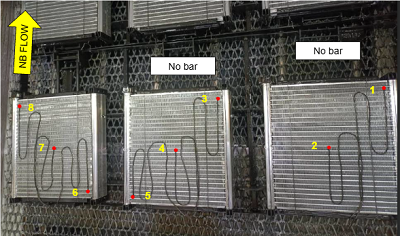


 🎉 METADATA EXTRACTION & FURNACE (NB3) CONFIRMATION COMPLETE!


In [4]:
# ==========================================================
# CELL 3: FILE METADATA, COMMENTS, RECIPE & EMBEDDED IMAGE
# ==========================================================
import os
import re
import zlib
import struct
import olefile
import io
import base64
import pandas as pd
from PIL import Image
from datetime import datetime, timedelta
from IPython.display import display as ipy_display, HTML

print("==========================================================")
print(" CELL 3: FILE METADATA, COMMENTS, RECIPE & EMBEDDED IMAGE")
print("==========================================================\n")

# SAFE DECOMPRESSION WITH UNCOMPRESSED FALLBACK
def decompress_bytes(raw_bytes):
    zlib_bytes = raw_bytes[8:] if raw_bytes.startswith(b'ZLIB') else raw_bytes
    try:
        return zlib.decompress(zlib_bytes)
    except Exception:
        try:
            return zlib.decompress(zlib_bytes, -zlib.MAX_WBITS)
        except Exception:
            return raw_bytes

def extract_clean_text_sentence(raw_text, keyword_marker=None):
    """Extracts standard readable ASCII sentences and strips binary noise."""
    if not raw_text:
        return "Not Found"

    if keyword_marker and keyword_marker in raw_text:
        raw_text = raw_text.split(keyword_marker, 1)[-1]

    matches = re.findall(r'[a-zA-Z0-9\s\-_/\.,:=#()%°℃+<]{5,}', raw_text)

    clean_parts = []
    for m in matches:
        m_str = m.strip()
        if re.search(r'33333|ffff|ffffff|\b[A-Za-z]@', m_str):
            break
        if len(m_str) > 2:
            clean_parts.append(m_str)

    result = " ".join(clean_parts).strip()
    result = re.split(r'\\cho1-sv|S:\\|CZoom|CProbeMapEntry|CFurnaceRecipe', result)[0].strip()
    return result if result else "Not Found"

if 'paq_file' not in globals() or not os.path.exists(paq_file):
    print("❌ Error: No active file found in memory. Please run Cell 1 first.")
else:
    file_name = os.path.basename(paq_file)
    ole = olefile.OleFileIO(paq_file)

    print("=" * 80)
    print(f"📦 EXTRACTED METADATA SUMMARY FOR: {file_name}")
    print("=" * 80)

    # 1. PARSE DATE & TIMESTAMPS
    fn_date = "N/A"
    fn_match = re.search(r'(\d{2})(\d{2})(20\d{2})', file_name)
    if fn_match:
        day, month, year = fn_match.groups()
        fn_date = f"{year}-{month}-{day}"

    exact_start = "N/A"
    ole_epoch = datetime(1899, 12, 30)
    target_streams = [s for s in ole.listdir() if "Trigger" in "/".join(s) or "Reset" in "/".join(s)]

    for s_path in target_streams:
        try:
            raw_data = ole.openstream(s_path).read()
            decomp = decompress_bytes(raw_data)
            for offset in range(0, len(decomp) - 8, 2):
                val = struct.unpack("<d", decomp[offset:offset+8])[0]
                if 43831.0 <= val <= 47482.0:
                    dt = ole_epoch + timedelta(days=val)
                    if dt.strftime('%H:%M:%S') != '00:00:00':
                        exact_start = dt.strftime('%Y-%m-%d %H:%M:%S')
                        break
        except Exception:
            pass

    # 2. PARSE OPERATOR NOTES, RECIPE, PROBE MAP & EMBEDDED IMAGE
    operator_notes = "Not Found"
    recipe_parameters = "Not Found"
    probe_locations = {}
    extracted_img = embedded_img if 'embedded_img' in globals() else None

    for s_path in ole.listdir():
        stream_name = "/".join(s_path)
        raw_stream = ole.openstream(s_path).read()
        decomp = decompress_bytes(raw_stream)
        text_decoded = decomp.decode('latin-1', errors='ignore')

        # Text Notes & Recipe
        if stream_name.endswith("Paqfiles/Paqfile0/ClassData"):
            operator_notes = extract_clean_text_sentence(text_decoded, keyword_marker="CPaqfile")

        elif stream_name.endswith("Recipe/ClassData"):
            recipe_parameters = extract_clean_text_sentence(text_decoded, keyword_marker="CRecipe")

        elif "Product/Probes/Probe" in stream_name and stream_name.endswith("/ClassData"):
            probe_num_match = re.search(r'Probe(\d+)', stream_name)
            if probe_num_match:
                p_idx = int(probe_num_match.group(1))
                ch_tag = f"PB#{p_idx + 1}"

                label_text = text_decoded
                if "CProbeMapEntry" in text_decoded:
                    label_text = text_decoded.split("CProbeMapEntry")[0]

                clean_loc = extract_clean_text_sentence(label_text, keyword_marker="CProbe")

                # --- STRIP LEADING SINGLE-LETTER BINARY ARTIFACTS ---
                if clean_loc != "Not Found":
                    clean_loc = re.sub(r'^[A-Z](?=[A-Z][a-z])', '', clean_loc)

                probe_locations[ch_tag] = clean_loc if clean_loc != "Not Found" else "Unlabeled"

        # Search for Embedded Raster Image Binary
        if extracted_img is None and len(decomp) > 500:
            png_idx = decomp.find(b'\x89PNG\r\n\x1a\n')
            if png_idx != -1:
                try: extracted_img = Image.open(io.BytesIO(decomp[png_idx:]))
                except: pass

            jpg_idx = decomp.find(b'\xff\xd8\xff')
            if extracted_img is None and jpg_idx != -1:
                try: extracted_img = Image.open(io.BytesIO(decomp[jpg_idx:]))
                except: pass

            bmp_idx = decomp.find(b'BM')
            if extracted_img is None and bmp_idx != -1:
                try: extracted_img = Image.open(io.BytesIO(decomp[bmp_idx:]))
                except: pass

    # --- STRICT FURNACE IDENTIFICATION (CONFIRMED IN SECTION 3: RECIPE PARAMETERS) ---
    furnace_id = "NB3"  # Default fallback

    # 1. PRIORITY 1: Check Section 3 Recipe Settings (e.g. '.rec' file path like 'NB#1', 'NB 1', 'NB-1', 'NB Furnace 01')
    rec_match = re.search(r'NB\s*Furnace\s*0?([123])\b|NB\s*#?\s*0?([123])\b|NB-0?([123])\b', recipe_parameters, re.IGNORECASE)

    # 2. PRIORITY 2: Check Section 1 Operator Comments
    note_match = re.search(r'NB\s*Furnace\s*0?([123])\b|NB\s*#?\s*0?([123])\b|NB-0?([123])\b', operator_notes, re.IGNORECASE)

    # 3. PRIORITY 3: Check Filename
    fn_f_match = re.search(r'NB\s*#?\s*0?([123])\b|NB-0?([123])\b', file_name, re.IGNORECASE)

    if rec_match:
        num = [g for g in rec_match.groups() if g is not None][0]
        furnace_id = f"NB{num}"
    elif note_match:
        num = [g for g in note_match.groups() if g is not None][0]
        furnace_id = f"NB{num}"
    elif fn_f_match:
        num = [g for g in fn_f_match.groups() if g is not None][0]
        furnace_id = f"NB{num}"

    # Save to global variables for export cells and Cell 4.1
    operator_comment = operator_notes
    process_settings = recipe_parameters
    embedded_img = extracted_img

    # --- DISPLAY METADATA, PROBE MAP & SETTINGS ---
    print("\n📝 1. OPERATOR NOTES & RECORDING TIMESTAMPS:")
    print(f"   • Filename Date Tag:      {fn_date}")
    print(f"   • Confirmed Start Time:   {exact_start}")
    print(f"   • Operator Comments:      \"{operator_notes}\"")

    print("\n📍 2. PROBE THERMOCOUPLE LOCATION MAP:")
    if probe_locations:
        sorted_probes = dict(sorted(probe_locations.items(), key=lambda x: int(x[0].replace("PB#", ""))))
        df_probe_map = pd.DataFrame([{"Channel": k, "Attached Location": v} for k, v in sorted_probes.items()])

        map_html = f'''
        <div style="width:100%; font-family:Arial, sans-serif; font-size:12px; margin-top:6px; border:1px solid #ccc; border-radius:4px; padding:6px;">
            {df_probe_map.to_html(index=False, classes="table table-striped", justify="left")}
        </div>
        '''
        ipy_display(HTML(map_html))
    else:
        print("   • No explicit probe location mapping entries found.")

    print("\n⚙️ 3. FURNACE OPERATING PARAMETERS & RECIPE SETTINGS:")
    recipe_bullets = recipe_parameters.replace(", ", "\n   • ").replace(" NB ", "\n   • NB ")
    print(f"   • {recipe_bullets}")
    print(f"   • Confirmed Furnace:      🔥 {furnace_id}")

    # --- DISPLAY EMBEDDED RASTER IMAGE ---
    if embedded_img is not None:
        buffered = io.BytesIO()
        embedded_img.save(buffered, format="PNG")
        img_b64 = base64.b64encode(buffered.getvalue()).decode()
        print("\n🖼️ 4. EMBEDDED RASTER IMAGE:")
        ipy_display(HTML(f'''
            <div style="margin-top:8px;">
                <img src="data:image/png;base64,{img_b64}"
                     style="max-width:850px; width:100%; height:auto; border:2px solid #003366; border-radius:6px; padding:4px;"/>
            </div>
        '''))
    else:
        print("\n🖼️ 4. EMBEDDED RASTER IMAGE:\n   • Note: No embedded raster image binary found in this .paq stream.")

    print("\n" + "=" * 80)
    print(f" 🎉 METADATA EXTRACTION & FURNACE ({furnace_id}) CONFIRMATION COMPLETE!")
    print("=" * 80)

Cell 4: Plot Interactive Graph with Zone Colors

4.1 Furnace number setting.

In [5]:
# ==========================================================
# CELL 4.1: FURNACE CONFIGURATION & ZONE SETTINGS
# ==========================================================
import os
import re

print("==========================================================")
print(" CELL 4.1: FURNACE CONFIGURATION & ZONE SETTINGS")
print("==========================================================\n")

# Detect active furnace from Cell 3 (Default to NB3 if not set)
active_furnace = furnace_id if 'furnace_id' in globals() else "NB3"

# ------------------------------------------------------------------------------
# GROUP COLOR DEFINITIONS FOR VISUALIZATION
# ------------------------------------------------------------------------------
GROUP_COLORS = {
    "Dryer":    "rgba(255, 235, 156, 0.30)",  # Soft Yellow
    "Debinder": "rgba(255, 199, 119, 0.30)",  # Soft Orange
    "Heating":  "rgba(255, 160, 160, 0.25)",  # Soft Red
    "Cooling":  "rgba(173, 216, 230, 0.30)"   # Soft Blue
}

# ------------------------------------------------------------------------------
# FURNACE PROFILES CONFIGURATION DATABASE (NB1, NB2, NB3)
# ------------------------------------------------------------------------------
FURNACE_CONFIGS = {
    # --- NB1: 23 ZONES WITH DEBINDER STAGE ---
    "NB1": {
        "line_speed_mpm": 1.400,            # 1.400 m/min
        "zones": [
            {"num": 1,  "name": "Dryer Z#1",        "start": 0.00,  "length": 3.15, "group": "Dryer"},
            {"num": 2,  "name": "Dryer Z#2",        "start": 3.15,  "length": 3.13, "group": "Dryer"},
            {"num": 3,  "name": "EXT Dryer",        "start": 6.27,  "length": 0.70, "group": "Dryer"},
            {"num": 4,  "name": "ENT DB",           "start": 6.97,  "length": 0.67, "group": "Debinder"},
            {"num": 5,  "name": "DB Z#1",           "start": 7.64,  "length": 3.13, "group": "Debinder"},
            {"num": 6,  "name": "DB Z#2",           "start": 10.77, "length": 2.60, "group": "Debinder"},
            {"num": 7,  "name": "DB Z#3",           "start": 13.37, "length": 2.60, "group": "Debinder"},
            {"num": 8,  "name": "DB Z#4",           "start": 15.97, "length": 3.13, "group": "Debinder"},
            {"num": 9,  "name": "XFER#1",           "start": 19.10, "length": 2.71, "group": "Heating"},
            {"num": 10, "name": "Z#1",              "start": 21.81, "length": 3.14, "group": "Heating"},
            {"num": 11, "name": "Z#2",              "start": 24.95, "length": 2.68, "group": "Heating"},
            {"num": 12, "name": "Z#3",              "start": 27.63, "length": 2.72, "group": "Heating"},
            {"num": 13, "name": "Z#4",              "start": 30.35, "length": 2.04, "group": "Heating"},
            {"num": 14, "name": "Z#5",              "start": 32.39, "length": 2.00, "group": "Heating"},
            {"num": 15, "name": "Z#6",              "start": 34.39, "length": 2.00, "group": "Heating"},
            {"num": 16, "name": "Z#7",              "start": 36.39, "length": 2.29, "group": "Heating"},
            {"num": 17, "name": "WatCool#1",        "start": 38.68, "length": 2.39, "group": "Cooling"},
            {"num": 18, "name": "WatCool#2",        "start": 41.07, "length": 1.90, "group": "Cooling"},
            {"num": 19, "name": "Exit curtain box", "start": 42.97, "length": 1.90, "group": "Cooling"},
            {"num": 20, "name": "XFER#2",           "start": 44.87, "length": 0.60, "group": "Cooling"},
            {"num": 21, "name": "Air Cool#1",       "start": 45.47, "length": 1.25, "group": "Cooling"},
            {"num": 22, "name": "Air Cool#2",       "start": 46.72, "length": 1.25, "group": "Cooling"},
            {"num": 23, "name": "Exit",             "start": 47.97, "length": 1.85, "group": "Cooling"},
        ],
        "stages": [
            {"Stage": "Dryer",    "Start (m)": 0.00,  "End (m)": 6.28,  "thresh": 200.0},
            {"Stage": "Debinder", "Start (m)": 7.64,  "End (m)": 19.10, "thresh": 300.0},
            {"Stage": "Brazing",  "Start (m)": 21.81, "End (m)": 42.97, "thresh": 577.0},
        ],
        "trigger_temp_brazing": 577.0,
        "dryer_dwell_thresh": 200.0,
        "debinder_dwell_thresh": 300.0,
        "brazing_dwell_thresh_1": 550.0,
        "brazing_dwell_thresh_2": 577.0,
        "brazing_dwell_thresh_3": 591.0,
    },

    # --- NB2: 17 ZONES (1.560 m/min / 1560 mm/min) ---
    "NB2": {
        "line_speed_mpm": 1.560,            # 1.560 m/min (1560 mm/min)
        "zones": [
            {"num": 1,  "name": "DryOff-Z#1",       "start": 0.00,  "length": 2.80, "group": "Dryer"},
            {"num": 2,  "name": "DryOff-Z#2",       "start": 2.80,  "length": 2.80, "group": "Dryer"},
            {"num": 3,  "name": "Xfer1",            "start": 5.60,  "length": 3.13, "group": "Dryer"},
            {"num": 4,  "name": "Z#1",              "start": 8.73,  "length": 3.60, "group": "Heating"},
            {"num": 5,  "name": "Z#2",              "start": 12.33, "length": 2.70, "group": "Heating"},
            {"num": 6,  "name": "Z#3",              "start": 15.03, "length": 2.40, "group": "Heating"},
            {"num": 7,  "name": "Z#4",              "start": 17.43, "length": 2.10, "group": "Heating"},
            {"num": 8,  "name": "Z#5",              "start": 19.53, "length": 2.30, "group": "Heating"},
            {"num": 9,  "name": "Z#6",              "start": 21.83, "length": 1.90, "group": "Heating"},
            {"num": 10, "name": "Z#7",              "start": 23.73, "length": 2.20, "group": "Heating"},
            {"num": 11, "name": "Xfer2",            "start": 25.93, "length": 0.80, "group": "Heating"},
            {"num": 12, "name": "Watcol1",          "start": 26.73, "length": 1.75, "group": "Cooling"},
            {"num": 13, "name": "Watcol2",          "start": 28.48, "length": 1.85, "group": "Cooling"},
            {"num": 14, "name": "Exit curtain box", "start": 30.33, "length": 2.30, "group": "Cooling"},
            {"num": 15, "name": "Airc1",            "start": 32.63, "length": 1.25, "group": "Cooling"},
            {"num": 16, "name": "Airc2",            "start": 33.88, "length": 1.25, "group": "Cooling"},
            {"num": 17, "name": "Exit",             "start": 35.13, "length": 1.80, "group": "Cooling"},
        ],
        "stages": [
            {"Stage": "Dryer",    "Start (m)": 0.00, "End (m)": 5.60,  "thresh": 200.0},
            {"Stage": "Brazing",  "Start (m)": 8.73, "End (m)": 30.33, "thresh": 577.0},
        ],
        "trigger_temp_brazing": 577.0,
        "dryer_dwell_thresh": 200.0,
        "debinder_dwell_thresh": None,
        "brazing_dwell_thresh_1": 550.0,
        "brazing_dwell_thresh_2": 577.0,
        "brazing_dwell_thresh_3": 591.0,
    },

    # --- NB3: 19 ZONES (1.270 m/min) ---
    "NB3": {
        "line_speed_mpm": 1.270,            # 1.270 m/min
        "zones": [
            {"num": 1,  "name": "XFER",             "start": 0.00,  "length": 0.10, "group": "Dryer"},
            {"num": 2,  "name": "Dryer#1",          "start": 0.10,  "length": 1.85, "group": "Dryer"},
            {"num": 3,  "name": "Dryer#2",          "start": 1.95,  "length": 1.85, "group": "Dryer"},
            {"num": 4,  "name": "Dryer#3",          "start": 3.80,  "length": 1.95, "group": "Dryer"},
            {"num": 5,  "name": "XFER#1",           "start": 5.75,  "length": 3.39, "group": "Dryer"},
            {"num": 6,  "name": "Z#1",              "start": 9.14,  "length": 3.60, "group": "Heating"},
            {"num": 7,  "name": "Z#2",              "start": 12.74, "length": 2.75, "group": "Heating"},
            {"num": 8,  "name": "Z#3",              "start": 15.49, "length": 2.30, "group": "Heating"},
            {"num": 9,  "name": "Z#4",              "start": 17.79, "length": 2.10, "group": "Heating"},
            {"num": 10, "name": "Z#5",              "start": 19.89, "length": 2.10, "group": "Heating"},
            {"num": 11, "name": "Z#6",              "start": 21.99, "length": 1.90, "group": "Heating"},
            {"num": 12, "name": "Z#7",              "start": 23.89, "length": 1.63, "group": "Heating"},
            {"num": 13, "name": "WatCoo#1",         "start": 25.52, "length": 2.56, "group": "Cooling"},
            {"num": 14, "name": "WatCoo#2",         "start": 28.08, "length": 1.90, "group": "Cooling"},
            {"num": 15, "name": "Exit curtain box", "start": 29.98, "length": 1.90, "group": "Cooling"},
            {"num": 16, "name": "XFER#2",           "start": 31.88, "length": 0.60, "group": "Cooling"},
            {"num": 17, "name": "AirCoo#1",         "start": 32.48, "length": 1.25, "group": "Cooling"},
            {"num": 18, "name": "AirCoo#2",         "start": 33.73, "length": 1.25, "group": "Cooling"},
            {"num": 19, "name": "Exit",             "start": 34.98, "length": 1.85, "group": "Cooling"},
        ],
        "stages": [
            {"Stage": "Dryer",    "Start (m)": 0.00, "End (m)": 5.75,  "thresh": 200.0},
            {"Stage": "Brazing",  "Start (m)": 9.14, "End (m)": 29.98, "thresh": 577.0},
        ],
        "trigger_temp_brazing": 577.0,
        "dryer_dwell_thresh": 200.0,
        "debinder_dwell_thresh": None,
        "brazing_dwell_thresh_1": 550.0,
        "brazing_dwell_thresh_2": 577.0,
        "brazing_dwell_thresh_3": 591.0,
    }
}

# Load Configuration for Active Furnace
cfg = FURNACE_CONFIGS.get(active_furnace, FURNACE_CONFIGS["NB3"])

LINE_SPEED_MPM = cfg["line_speed_mpm"]
FURNACE_ZONES = cfg["zones"]
PROCESS_STAGES = cfg["stages"]
TRIGGER_TEMP_BRAZING = cfg["trigger_temp_brazing"]
DRYER_DWELL_THRESH = cfg["dryer_dwell_thresh"]
DEBINDER_DWELL_THRESH = cfg["debinder_dwell_thresh"]
BRAZING_DWELL_THRESH_1 = cfg["brazing_dwell_thresh_1"]
BRAZING_DWELL_THRESH_2 = cfg["brazing_dwell_thresh_2"]
BRAZING_DWELL_THRESH_3 = cfg["brazing_dwell_thresh_3"]


# ------------------------------------------------------------------------------
# AUTOMATIC RECIPE LINE SPEED CONFIRMATION / OVERRIDE (FROM CELL 3 TEXT)
# Target: Must begin with "CV SP" and take the LAST match if multiple exist
# ------------------------------------------------------------------------------
recipe_text_corpus = ""
if 'process_settings' in globals() and process_settings:
    recipe_text_corpus += f" {process_settings}"
if 'operator_comment' in globals() and operator_comment:
    recipe_text_corpus += f" {operator_comment}"

speed_found = False
if recipe_text_corpus:
    # 1. Target specifically "CV SP" patterns and capture all occurrences
    # Matches: "CV SP=1575 mm/ min", "CV SP: 1400 mm/min", "CV SP = 1575"
    cv_sp_matches = re.findall(
        r'CV\s*SP\s*[:=]?\s*(\d{3,4})\s*(?:mm/\s*min|mm)?',
        recipe_text_corpus,
        re.IGNORECASE
    )

    if cv_sp_matches:
        # Take the LAST match found in the text corpus
        last_speed_val = float(cv_sp_matches[-1])

        # Validation range: Accept speeds between 800 mm/min and 2500 mm/min
        if 800.0 <= last_speed_val <= 2500.0:
            LINE_SPEED_MPM = last_speed_val / 1000.0
            speed_found = True
    else:
        # Fallback: Check for m/min format (e.g., "1.575 m/min") and take the last match
        m_matches = re.findall(r'(\d+\.\d+)\s*(?:m/min|mpm)', recipe_text_corpus, re.IGNORECASE)
        if m_matches:
            last_m_val = float(m_matches[-1])
            if 0.800 <= last_m_val <= 2.500:
                LINE_SPEED_MPM = last_m_val
                speed_found = True

# ------------------------------------------------------------------------------
# DYNAMICALLY SPLIT df_master INTO STAGE DATAFRAMES
# ------------------------------------------------------------------------------
if 'df_master' in globals() and df_master is not None and 'detected_start_sec' in globals():
    df_master["Distance_Meters"] = ((df_master["Time_Seconds"] - detected_start_sec) / 60.0) * LINE_SPEED_MPM

    for stg in PROCESS_STAGES:
        stg_name = stg["Stage"].lower()
        sub_df = df_master[
            (df_master["Distance_Meters"] >= stg["Start (m)"]) &
            (df_master["Distance_Meters"] <= stg["End (m)"])
        ]
        globals()[f"df_{stg_name}"] = sub_df

    if "debinder" not in [s["Stage"].lower() for s in PROCESS_STAGES]:
        globals()["df_debinder"] = None

    if 'probe_start_info' in globals():
        for col in [c for c in df_master.columns if c.startswith("PB#")]:
            p_sec = probe_start_info.get(col, {}).get("Start_Sec", 0)
            df_master[f"Distance_{col}"] = ((df_master["Time_Seconds"] - p_sec) / 60.0) * LINE_SPEED_MPM

print(f" 🔥 Active Furnace Profile Loaded: {active_furnace}")
print(f" ⚙️ Conveyor Line Speed:      {LINE_SPEED_MPM:.3f} m/min ({int(LINE_SPEED_MPM*1000)} mm/min) {'[CONFIRMED FROM RECIPE]' if speed_found else '[PROFILE DEFAULT]'}")
print(f" 📐 Total Configured Zones:    {len(FURNACE_ZONES)}")
print(f" 🏭 Process Stages Configured: {[s['Stage'] for s in PROCESS_STAGES]}")
print(f" 🌡️ Brazing Trigger Temp:      {TRIGGER_TEMP_BRAZING}°C")
print(f" ⏱️ Dryer Dwell Threshold:     ≥{DRYER_DWELL_THRESH}°C")
if DEBINDER_DWELL_THRESH:
    print(f" ⏱️ Debinder Dwell Threshold:  ≥{DEBINDER_DWELL_THRESH}°C")
print(f" ⏱️ Brazing Dwell Thresholds:   ≥{BRAZING_DWELL_THRESH_1}°C | ≥{BRAZING_DWELL_THRESH_2}°C | ≥{BRAZING_DWELL_THRESH_3}°C")

 CELL 4.1: FURNACE CONFIGURATION & ZONE SETTINGS

 🔥 Active Furnace Profile Loaded: NB3
 ⚙️ Conveyor Line Speed:      1.270 m/min (1270 mm/min) [PROFILE DEFAULT]
 📐 Total Configured Zones:    19
 🏭 Process Stages Configured: ['Dryer', 'Brazing']
 🌡️ Brazing Trigger Temp:      577.0°C
 ⏱️ Dryer Dwell Threshold:     ≥200.0°C
 ⏱️ Brazing Dwell Thresholds:   ≥550.0°C | ≥577.0°C | ≥591.0°C


Cell 4.2 plot graph

In [6]:
# ==========================================================
# CELL 4.2: INTERACTIVE GRAPHS & INDIVIDUAL PROBE START ALIGNMENT
# ==========================================================
import os
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import display, HTML

print("==========================================================")
print(" CELL 4.2: INTERACTIVE GRAPHS & INDIVIDUAL PROBE START ALIGNMENT")
print("==========================================================\n")

if 'df_master' not in globals() or df_master.empty:
    print("❌ Error: No master data found in memory. Please run Cell 2 first.")
elif 'FURNACE_ZONES' not in globals():
    print("❌ Error: Furnace configuration not found. Please run Cell 4.1 first.")
else:
    probe_cols = [c for c in df_master.columns if c.startswith("PB#")]
    time_mins = df_master["Time_Seconds"] / 60.0

    plot_title = os.path.basename(paq_file).replace(".paq", "") if 'paq_file' in globals() else "PAQ File"

    # ==========================================================================
    # CHART 1: GLOBAL FURNACE PROFILE CHART (GLOBAL DISTANCE ALIGNMENT)
    # ==========================================================================
    custom_hover_data1 = np.stack(
        (df_master["Time_HHMMSS"], df_master["Time_Seconds"], df_master["Distance_Meters"]),
        axis=-1
    )

    fig1 = go.Figure()

    for col in probe_cols:
        fig1.add_trace(
            go.Scatter(
                x=df_master["Distance_Meters"],
                y=df_master[col],
                mode="lines",
                name=col,
                customdata=custom_hover_data1,
                hovertemplate=(
                    "<b>%{fullData.name}</b>: <b style='font-size:14px;'>%{y:.1f} °C</b><br>"
                    "Time: %{customdata[0]} (%{customdata[1]}s)<extra></extra>"
                )
            )
        )

    for z in FURNACE_ZONES:
        z_start = z["start"]
        z_end = z["start"] + z["length"]
        z_color = GROUP_COLORS.get(z["group"], "rgba(200, 200, 200, 0.2)")

        fig1.add_vrect(
            x0=z_start, x1=z_end, fillcolor=z_color, layer="below",
            line_width=0.5, line_dash="dot", line_color="rgba(120, 120, 120, 0.4)",
            annotation_text=f"<b>{z['num']}.{z['name']}</b>",
            annotation_position="top left",
            annotation=dict(font_size=9, font_color="#222222", textangle=-90)
        )

    fig1.add_hline(y=TRIGGER_TEMP_BRAZING, line_dash="dash", line_color="red", line_width=1.5,
                   annotation_text=f"<b>Brazing Temp Threshold ({TRIGGER_TEMP_BRAZING}°C)</b>", annotation_position="bottom right")

    fig1.add_vline(x=0.0, line_dash="solid", line_color="green", line_width=2,
                   annotation_text=" <b>First Probe Entrance (0.0 m)</b>", annotation_position="bottom right")

    fig1.update_layout(
        title=f"<b>CHART 1: GLOBAL FURNACE PROFILE ({active_furnace} GLOBAL DISTANCE):</b> {plot_title}",
        xaxis=dict(title="Furnace Distance (Meters from Entrance)", showgrid=True, gridcolor='rgba(220, 220, 220, 0.5)', zeroline=True, zerolinecolor='black'),
        xaxis2=dict(title="Elapsed Time (Minutes)", overlaying="x", side="top", range=[time_mins.min(), time_mins.max()], showgrid=False),
        yaxis=dict(title="Temperature (°C)", showgrid=True, gridcolor='rgba(220, 220, 220, 0.5)'),
        hovermode="x unified",
        template="plotly_white",
        height=600,
        legend=dict(title="Probes", x=1.01, y=1, bordercolor="LightGray", borderwidth=1)
    )

    fig1.show()

    # ==========================================================================
    # DISPLAY PROBE INDIVIDUAL START ALIGNMENT SUMMARY TABLE
    # ==========================================================================
    print("\n" + "=" * 80)
    print(" 📊 INDIVIDUAL PROBE START POINT ALIGNMENT SUMMARY (60°C ENTRY)")
    print("=" * 80)

    shift_table_rows = []
    if 'probe_start_info' in globals():
        for col, info in probe_start_info.items():
            status = "🏆 First (Lead Probe)" if info["Is_First"] else f"+{info['Offset_Meters']:.2f} m lag"
            shift_table_rows.append({
                "Probe": col,
                "Start Time (HH:MM:SS)": info["Start_HHMMSS"],
                "Start Sec": f"{info['Start_Sec']}s",
                "Lag Time vs First Probe": f"+{info['Offset_Sec']}s" if info['Offset_Sec'] > 0 else "0s (Lead)",
                "Distance Shift vs First Probe": f"+{info['Offset_Meters']:.2f} m" if info['Offset_Meters'] > 0 else "0.00 m (Lead)",
                "Status": status
            })

    df_shift_summary = pd.DataFrame(shift_table_rows)

    table_html = f'''
    <div style="width:85%; font-family:Arial, sans-serif; font-size:12px; margin-top:8px; border:1px solid #ccc; padding:4px;">
        {df_shift_summary.to_html(index=False, classes="table table-striped")}
    </div>
    '''
    display(HTML(table_html))

    # ==========================================================================
    # CHART 2: INDIVIDUALLY ALIGNED PROBE CHART WITH SHADED ZONES
    # ==========================================================================
    fig2 = go.Figure()

    # 1. Add probe temperature lines using each probe's own distance column
    for col in probe_cols:
        offset_m = probe_start_info[col]["Offset_Meters"] if 'probe_start_info' in globals() else 0.0

        indiv_hover_data = np.stack(
            (df_master["Time_HHMMSS"], df_master["Time_Seconds"], np.full(len(df_master), offset_m)),
            axis=-1
        )

        fig2.add_trace(
            go.Scatter(
                x=df_master[f"Distance_{col}"],
                y=df_master[col],
                mode="lines",
                name=f"{col} (Lag: +{offset_m:.2f}m)" if offset_m > 0 else f"{col} (Lead)",
                customdata=indiv_hover_data,
                hovertemplate=(
                    "<b>%{fullData.name}</b>: <b style='font-size:14px;'>%{y:.1f} °C</b><br>"
                    "Indiv Distance: <b>%{x:.2f} m</b><br>"
                    "Time: %{customdata[0]} (%{customdata[1]}s)<br>"
                    "Shift vs 1st Probe: +%{customdata[2]:.2f} m<extra></extra>"
                )
            )
        )

    # 2. Add shaded zone backgrounds & labels to Chart 2
    for z in FURNACE_ZONES:
        z_start = z["start"]
        z_end = z["start"] + z["length"]
        z_color = GROUP_COLORS.get(z["group"], "rgba(200, 200, 200, 0.2)")

        fig2.add_vrect(
            x0=z_start, x1=z_end, fillcolor=z_color, layer="below",
            line_width=0.5, line_dash="dot", line_color="rgba(120, 120, 120, 0.4)",
            annotation_text=f"<b>{z['num']}.{z['name']}</b>",
            annotation_position="top left",
            annotation=dict(font_size=9, font_color="#222222", textangle=-90)
        )

    # 3. Reference lines for Chart 2
    fig2.add_vline(x=0.0, line_dash="solid", line_color="blue", line_width=2,
                   annotation_text=" <b>Individual Probe Entry (0.0 m / 60°C)</b>", annotation_position="bottom right")

    fig2.add_hline(y=TRIGGER_TEMP_BRAZING, line_dash="dash", line_color="red", line_width=1.5,
                   annotation_text=f"<b>Brazing Temp Threshold ({TRIGGER_TEMP_BRAZING}°C)</b>", annotation_position="bottom right")

    fig2.update_layout(
        title=f"<b>CHART 2: INDIVIDUALLY ALIGNED PROBE PROFILES ({active_furnace} - 0.0 m = OWN 60°C START):</b> {plot_title}",
        xaxis=dict(title="Individual Probe Distance (Meters from Probe's Own 60°C Entry)", showgrid=True, gridcolor='rgba(220, 220, 220, 0.5)', zeroline=True, zerolinecolor='black'),
        yaxis=dict(title="Temperature (°C)", showgrid=True, gridcolor='rgba(220, 220, 220, 0.5)'),
        hovermode="x unified",
        template="plotly_white",
        height=650,
        legend=dict(title="Probes & Shifts", x=1.01, y=1, bordercolor="LightGray", borderwidth=1)
    )

    fig2.show()

 CELL 4.2: INTERACTIVE GRAPHS & INDIVIDUAL PROBE START ALIGNMENT




 📊 INDIVIDUAL PROBE START POINT ALIGNMENT SUMMARY (60°C ENTRY)


Probe,Start Time (HH:MM:SS),Start Sec,Lag Time vs First Probe,Distance Shift vs First Probe,Status
PB#1,00:00:36,36s,+29s,+0.61 m,+0.61 m lag
PB#2,00:00:23,23s,+16s,+0.34 m,+0.34 m lag
PB#3,00:00:23,23s,+16s,+0.34 m,+0.34 m lag
PB#4,00:00:19,19s,+12s,+0.25 m,+0.25 m lag
PB#5,00:00:23,23s,+16s,+0.34 m,+0.34 m lag
PB#6,00:00:20,20s,+13s,+0.28 m,+0.28 m lag
PB#7,00:00:07,7s,0s (Lead),0.00 m (Lead),🏆 First (Lead Probe)
PB#8,00:00:11,11s,+4s,+0.08 m,+0.08 m lag


Cell 5: Summary Table with Temp Color in Each Zone

In [7]:
# ==========================================================
# CELL 5: MAXIMUM TEMPERATURE PER ZONE SUMMARY TABLE
# ==========================================================
import numpy as np
import pandas as pd
from IPython.display import display

print("==========================================================")
print(" CELL 5: MAXIMUM TEMPERATURE PER ZONE SUMMARY TABLE")
print("==========================================================\n")

# Verify that Cell 2 and Cell 4.1 have been executed
if 'df_master' in globals() and df_master is not None and 'FURNACE_ZONES' in globals():

    # Read active furnace label from Cell 3 / Cell 4.1
    active_furnace = globals().get('furnace_id', globals().get('active_furnace', 'Furnace'))

    # Identify active probe columns
    probe_cols = [col for col in df_master.columns if col.startswith("PB#")]

    if not probe_cols:
        print("⚠️ Warning: No probe columns starting with 'PB#' were found in df_master.")

    # Ensure Distance_Meters exists using LINE_SPEED_MPM established in Cell 4.1
    if "Distance_Meters" not in df_master.columns:
        start_sec = globals().get("detected_start_sec", 0)
        speed = globals().get("LINE_SPEED_MPM", 1.0)
        df_master["Distance_Meters"] = (
            (df_master["Time_Seconds"] - start_sec) / 60.0
        ) * speed

    # Process zones directly from FURNACE_ZONES (defined strictly in Cell 4.1)
    zone_max_records = []

    for z in FURNACE_ZONES:
        z_num = z["num"]
        z_name = z["name"]
        z_start = z["start"]
        z_end = round(z_start + z["length"], 2)
        z_group = z["group"]

        # Slice data strictly inside this zone's physical distance boundaries
        zone_df = df_master[
            (df_master["Distance_Meters"] >= z_start)
            & (df_master["Distance_Meters"] < z_end)
        ]

        row_dict = {
            "Group": z_group,
            "Zone #": z_num,
            "Zone Name": z_name,
            "Start (m)": z_start,
            "End (m)": z_end,
        }

        if not zone_df.empty and probe_cols:
            max_series = zone_df[probe_cols].max()

            for col in probe_cols:
                row_dict[col] = max_series[col]

            # Determine overall peak and identify the hot probe
            if max_series.notna().any():
                row_dict["Zone Peak (°C)"] = max_series.max()
                row_dict["Hot Probe"] = max_series.idxmax()
            else:
                row_dict["Zone Peak (°C)"] = np.nan
                row_dict["Hot Probe"] = "-"
        else:
            for col in probe_cols:
                row_dict[col] = np.nan
            row_dict["Zone Peak (°C)"] = np.nan
            row_dict["Hot Probe"] = "-"

        zone_max_records.append(row_dict)

    # Convert to DataFrame
    df_zone_summary = pd.DataFrame(zone_max_records)
    display_df = df_zone_summary.set_index(["Group", "Zone #", "Zone Name"])

    # Calculate gradient limits based on actual data bounds
    styled_cols = probe_cols + ["Zone Peak (°C)"]
    numeric_data = display_df[styled_cols].to_numpy()

    v_min = (
        float(np.nanmin(numeric_data))
        if np.issubdtype(numeric_data.dtype, np.number) and not np.isnan(numeric_data).all()
        else 50.0
    )
    v_max = (
        float(np.nanmax(numeric_data))
        if np.issubdtype(numeric_data.dtype, np.number) and not np.isnan(numeric_data).all()
        else 620.0
    )

    # Apply Pandas Styling
    caption_text = f"Peak Probe Temperatures Across All {len(FURNACE_ZONES)} {active_furnace} Furnace Zones"

    styled_table = (
        display_df.style.format(
            {col: "{:.1f}" for col in styled_cols if col in display_df.columns},
            na_rep="-",
        )
        .background_gradient(
            cmap="OrRd", subset=styled_cols, vmin=v_min, vmax=v_max
        )
        .set_properties(
            **{
                "text-align": "center",
                "font-size": "12px",
                "vertical-align": "middle",
            }
        )
        .set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("text-align", "center"),
                        ("font-weight", "bold"),
                    ],
                },
                {
                    "selector": "caption",
                    "props": [
                        ("font-size", "14px"),
                        ("font-weight", "bold"),
                        ("color", "#003366"),
                        ("margin-bottom", "8px"),
                    ],
                }
            ]
        )
        .set_caption(caption_text)
    )

    current_speed = globals().get("LINE_SPEED_MPM", "N/A")
    print(f" ✓ Consuming {len(FURNACE_ZONES)} zones directly from Cell 4.1 for 🔥 {active_furnace} (Line Speed: {current_speed} m/min)\n")
    display(styled_table)

else:
    print("❌ Error: Missing master dataset or zone settings. Please run Cell 2 and Cell 4.1 first.")

 CELL 5: MAXIMUM TEMPERATURE PER ZONE SUMMARY TABLE

 ✓ Consuming 19 zones directly from Cell 4.1 for 🔥 NB3 (Line Speed: 1.27 m/min)



Cell 6: Main 3 Zone Summary + Google Sheets Isolated Column Copier

In [8]:
# ==========================================================
# CELL 6: MAIN STAGES, DYNAMIC ZONE MATRIX & COLUMN COPIER
# ==========================================================
import os
import numpy as np
import pandas as pd
from IPython.display import display, HTML

print("==========================================================")
print(" CELL 6: MAIN STAGES, DYNAMIC ZONE MATRIX & COLUMN COPIER")
print("==========================================================\n")

# Detect active furnace ID from Cell 3 / Cell 4.1
active_furnace = globals().get('furnace_id', globals().get('active_furnace', 'Furnace'))

# Read dynamic settings directly from Cell 4.1
zones_list = globals().get('FURNACE_ZONES', [])
stages_list = globals().get('PROCESS_STAGES', [
    {"Stage": "Dryer", "Start (m)": 0.00, "End (m)": 5.75, "thresh": 200.0},
    {"Stage": "Brazing", "Start (m)": 9.14, "End (m)": 29.98, "thresh": 577.0}
])

dryer_thresh = globals().get('DRYER_DWELL_THRESH', 200.0)
debinder_thresh = globals().get('DEBINDER_DWELL_THRESH', 300.0)
brz_thresh_1 = globals().get('BRAZING_DWELL_THRESH_1', 550.0)
brz_thresh_2 = globals().get('BRAZING_DWELL_THRESH_2', 577.0)
brz_thresh_3 = globals().get('BRAZING_DWELL_THRESH_3', 591.0)
brz_trigger_temp = globals().get('TRIGGER_TEMP_BRAZING', 577.0)

def format_dwell_time(total_seconds):
    """Formats duration in seconds to HH:MM:SS format"""
    m, s = divmod(total_seconds, 60)
    h, m = divmod(m, 60)
    return f"{int(h):02d}:{int(m):02d}:{int(s):02d}"

if "df_master" in globals() and df_master is not None and zones_list:
    probe_cols = [col for col in df_master.columns if col.startswith("PB#")]

    # Divide probes into bottom and top groups
    bottom_probes = [col for col in probe_cols if col in ["PB#1", "PB#2", "PB#3", "PB#4"]]
    top_probes = [col for col in probe_cols if col in ["PB#5", "PB#6", "PB#7", "PB#8"]]
    if not bottom_probes and not top_probes and probe_cols:
        half_idx = len(probe_cols) // 2
        bottom_probes = probe_cols[:half_idx]
        top_probes = probe_cols[half_idx:]

    # Pre-calculate Independent Trigger Rows & Deltas for Brazing Stage
    brazing_info = next((stg for stg in stages_list if stg["Stage"] == "Brazing"), stages_list[-1])
    brazing_df = df_master[
        (df_master["Distance_Meters"] >= brazing_info["Start (m)"]) &
        (df_master["Distance_Meters"] <= brazing_info["End (m)"])
    ]

    # Bottom Group Trigger
    bot_trig_row, bot_delta = None, np.nan
    if not brazing_df.empty and bottom_probes:
        bot_mask = (brazing_df[bottom_probes] >= brz_trigger_temp).any(axis=1)
        if bot_mask.any():
            bot_trig_row = brazing_df[bot_mask].iloc[0]
            bot_delta = brz_trigger_temp - bot_trig_row[bottom_probes].min()

    # Top Group Trigger
    top_trig_row, top_delta = None, np.nan
    if not brazing_df.empty and top_probes:
        top_mask = (brazing_df[top_probes] >= brz_trigger_temp).any(axis=1)
        if top_mask.any():
            top_trig_row = brazing_df[top_mask].iloc[0]
            top_delta = brz_trigger_temp - top_trig_row[top_probes].min()

    # Check if Debinder Stage exists in stages_list
    has_debinder = any(stg["Stage"] == "Debinder" for stg in stages_list)

    # ==========================================================================
    # OUTPUT 1A: VISUAL INSPECTION MATRIX — MAIN PROCESS STAGES
    # ==========================================================================
    stage_matrix_rows = []

    # Pre-slice stage DataFrames
    dryer_info = next((stg for stg in stages_list if stg["Stage"] == "Dryer"), stages_list[0])
    dryer_df = df_master[
        (df_master["Distance_Meters"] >= dryer_info["Start (m)"]) &
        (df_master["Distance_Meters"] <= dryer_info["End (m)"])
    ]

    debinder_df = None
    if has_debinder:
        debinder_info = next(stg for stg in stages_list if stg["Stage"] == "Debinder")
        debinder_df = df_master[
            (df_master["Distance_Meters"] >= debinder_info["Start (m)"]) &
            (df_master["Distance_Meters"] <= debinder_info["End (m)"])
        ]

    for col in probe_cols:
        r_dict = {("Probe Details", "Probe"): col}

        # 1. Dryer Stage
        lbl_dryer = "Dryer Zone"
        if not dryer_df.empty:
            r_dict[(lbl_dryer, "Max (°C)")] = round(dryer_df[col].max(), 1)
            sec_dryer = (dryer_df[col] >= dryer_thresh).sum()
            r_dict[(lbl_dryer, f"Dwell (≥{int(dryer_thresh)}°C)")] = format_dwell_time(sec_dryer)
        else:
            r_dict[(lbl_dryer, "Max (°C)")] = np.nan
            r_dict[(lbl_dryer, f"Dwell (≥{int(dryer_thresh)}°C)")] = "00:00:00"

        # 2. Debinder Stage (If active for NB1)
        if has_debinder:
            lbl_db = "Debinder Zone"
            d_thresh = debinder_thresh if debinder_thresh else 300.0
            if debinder_df is not None and not debinder_df.empty:
                r_dict[(lbl_db, "Max (°C)")] = round(debinder_df[col].max(), 1)
                sec_db = (debinder_df[col] >= d_thresh).sum()
                r_dict[(lbl_db, f"Dwell (≥{int(d_thresh)}°C)")] = format_dwell_time(sec_db)
            else:
                r_dict[(lbl_db, "Max (°C)")] = np.nan
                r_dict[(lbl_db, f"Dwell (≥{int(d_thresh)}°C)")] = "00:00:00"

        # 3. Brazing Stage
        lbl_brz = "Brazing Zone"
        if not brazing_df.empty:
            r_dict[(lbl_brz, "Max (°C)")] = round(brazing_df[col].max(), 1)
            r_dict[(lbl_brz, f"Dwell (≥{int(brz_thresh_1)}°C)")] = format_dwell_time((brazing_df[col] >= brz_thresh_1).sum())
            r_dict[(lbl_brz, f"Dwell (≥{int(brz_thresh_2)}°C)")] = format_dwell_time((brazing_df[col] >= brz_thresh_2).sum())
            r_dict[(lbl_brz, f"Dwell (≥{int(brz_thresh_3)}°C)")] = format_dwell_time((brazing_df[col] >= brz_thresh_3).sum())

            # Trigger Temp Spreads & Deltas
            if col in bottom_probes:
                r_dict[(lbl_brz, f"Temp @ {int(brz_trigger_temp)}°C (°C)")] = round(bot_trig_row[col], 1) if bot_trig_row is not None else np.nan
                r_dict[(lbl_brz, f"Bot Δ ({int(brz_trigger_temp)}-Min)")] = round(bot_delta, 1) if pd.notna(bot_delta) else np.nan
                r_dict[(lbl_brz, f"Top Δ ({int(brz_trigger_temp)}-Min)")] = np.nan
            elif col in top_probes:
                r_dict[(lbl_brz, f"Temp @ {int(brz_trigger_temp)}°C (°C)")] = round(top_trig_row[col], 1) if top_trig_row is not None else np.nan
                r_dict[(lbl_brz, f"Top Δ ({int(brz_trigger_temp)}-Min)")] = round(top_delta, 1) if pd.notna(top_delta) else np.nan
                r_dict[(lbl_brz, f"Bot Δ ({int(brz_trigger_temp)}-Min)")] = np.nan
            else:
                r_dict[(lbl_brz, f"Temp @ {int(brz_trigger_temp)}°C (°C)")] = np.nan
                r_dict[(lbl_brz, f"Top Δ ({int(brz_trigger_temp)}-Min)")] = np.nan
                r_dict[(lbl_brz, f"Bot Δ ({int(brz_trigger_temp)}-Min)")] = np.nan

        stage_matrix_rows.append(r_dict)

    df_stage_matrix = pd.DataFrame(stage_matrix_rows)
    if not df_stage_matrix.empty:
        df_stage_matrix.columns = pd.MultiIndex.from_tuples(df_stage_matrix.columns)
        df_stage_matrix.set_index(("Probe Details", "Probe"), inplace=True)
        df_stage_matrix.index.name = "Probe"

    stages_title_str = "DRYER, DEBINDER & BRAZING" if has_debinder else "DRYER & BRAZING"
    print("=" * 110)
    print(f" 🔍 OUTPUT 1A: INSPECTION MATRIX — {stages_title_str} STAGES ({active_furnace})")
    print("=" * 110)
    display(df_stage_matrix.style.set_caption(f"{active_furnace} Inspection View: Max Temp, Dwells, and {int(brz_trigger_temp)}°C Spreads"))

    # ==========================================================================
    # OUTPUT 1B: VISUAL INSPECTION MATRIX — ALL FURNACE ZONES
    # ==========================================================================
    zone_matrix_rows = []
    for z in zones_list:
        z_start = z["start"]
        z_end = round(z_start + z["length"], 2)
        z_df = df_master[
            (df_master["Distance_Meters"] >= z_start) &
            (df_master["Distance_Meters"] < z_end)
        ]

        r_dict = {
            ("Zone Info", "Zone #"): z["num"],
            ("Zone Info", "Zone Name"): z["name"],
        }
        for col in probe_cols:
            if not z_df.empty:
                r_dict[(col, "Max (°C)")] = round(z_df[col].max(), 1)
                r_dict[(col, "Min (°C)")] = round(z_df[col].min(), 1)
            else:
                r_dict[(col, "Max (°C)")] = np.nan
                r_dict[(col, "Min (°C)")] = np.nan
        zone_matrix_rows.append(r_dict)

    df_zone_matrix = pd.DataFrame(zone_matrix_rows)
    if not df_zone_matrix.empty:
        df_zone_matrix.columns = pd.MultiIndex.from_tuples(df_zone_matrix.columns)
        df_zone_matrix.set_index([("Zone Info", "Zone #"), ("Zone Info", "Zone Name")], inplace=True)

    print("\n" + "=" * 110)
    print(f" 🔍 OUTPUT 1B: INSPECTION MATRIX — {len(zones_list)} {active_furnace} ZONES (MAX & MIN TEMP)")
    print("=" * 110)
    display(df_zone_matrix.style.set_caption(f"{active_furnace} Inspection View: {len(zones_list)} Furnace Zones Probe Max/Min Temperatures"))

    # ==========================================================================
    # 📋 ISOLATED SINGLE-COLUMN COPIER FOR GOOGLE SHEETS
    # ==========================================================================
    print("\n" + "=" * 110)
    print(" 📋 GOOGLE SHEETS ISOLATED COLUMN COPIER")
    print("=" * 110)
    print("💡 Click inside any box below (auto-highlights all probe values) -> Press Ctrl+C -> Paste into Google Sheets\n")

    html_output = """
    <style>
        .copy-container { display: flex; flex-wrap: wrap; gap: 12px; font-family: Arial, sans-serif; margin-top: 10px; }
        .copy-card { border: 1px solid #d1d5db; border-radius: 6px; padding: 8px; background-color: #f9fafb; box-shadow: 0 1px 3px rgba(0,0,0,0.08); text-align: center; }
        .copy-card h4 { margin: 0 0 6px 0; font-size: 11px; color: #1f2937; height: 32px; display: flex; align-items: center; justify-content: center; line-height: 1.2; }
        .copy-box { width: 125px; height: 165px; font-family: monospace; font-size: 13px; border: 1px solid #9ca3af; border-radius: 4px; padding: 6px; resize: none; background-color: #ffffff; text-align: center; line-height: 1.4; }
        .copy-box:focus { border-color: #2563eb; outline: none; box-shadow: 0 0 0 2px rgba(37, 99, 235, 0.2); }
    </style>
    <div class="copy-container">
    """

    for stage_col, metric_col in df_stage_matrix.columns:
        stage_title = stage_col.split('(')[0].strip()
        column_title = f"{stage_title}<br><b>{metric_col}</b>"

        vals = []
        for val in df_stage_matrix[(stage_col, metric_col)]:
            if isinstance(val, (int, float)):
                vals.append(f"{val:.1f}" if pd.notna(val) else "-")
            else:
                vals.append(str(val) if pd.notna(val) else "-")
        column_text = "\n".join(vals)

        html_output += f"""
        <div class="copy-card">
            <h4>{column_title}</h4>
            <textarea class="copy-box" readonly onclick="this.select();">{column_text}</textarea>
        </div>
        """

    html_output += "</div>"
    display(HTML(html_output))

else:
    print("❌ Error: Missing master dataset or furnace configuration. Please run Cell 2 and Cell 4.1 first.")

 CELL 6: MAIN STAGES, DYNAMIC ZONE MATRIX & COLUMN COPIER

 🔍 OUTPUT 1A: INSPECTION MATRIX — DRYER & BRAZING STAGES (NB3)



 🔍 OUTPUT 1B: INSPECTION MATRIX — 19 NB3 ZONES (MAX & MIN TEMP)



 📋 GOOGLE SHEETS ISOLATED COLUMN COPIER
💡 Click inside any box below (auto-highlights all probe values) -> Press Ctrl+C -> Paste into Google Sheets



Cell 7: Data Set Record (1 Row per File for Main Zone)

In [9]:
# ==========================================================
# CELL 7: UNIFIED 1-ROW DATASET FOR DATABASE STACKING (NB1/NB2/NB3)
# ==========================================================
import os
import numpy as np
import pandas as pd
from IPython.display import display, HTML

print("==========================================================")
print(" CELL 7: UNIFIED 1-ROW DATASET FOR DATABASE STACKING")
print("==========================================================\n")

active_furnace = globals().get('furnace_id', globals().get('active_furnace', 'NB3'))
stages_list = globals().get('PROCESS_STAGES', [])
zones_list = globals().get('FURNACE_ZONES', [])

dryer_thresh = globals().get('DRYER_DWELL_THRESH', 200.0)
debinder_thresh = globals().get('DEBINDER_DWELL_THRESH', 300.0)
brz_thresh_1 = globals().get('BRAZING_DWELL_THRESH_1', 550.0)
brz_thresh_2 = globals().get('BRAZING_DWELL_THRESH_2', 577.0)
brz_thresh_3 = globals().get('BRAZING_DWELL_THRESH_3', 591.0)
TRIGGER_TEMP_BRAZING = globals().get('TRIGGER_TEMP_BRAZING', 577.0)

def format_dwell_time(total_seconds):
    """Formats total duration in seconds into HH:MM:SS string format."""
    if pd.isna(total_seconds) or total_seconds == 0:
        return "00:00:00"
    m, s = divmod(total_seconds, 60)
    h, m = divmod(m, 60)
    return f"{int(h):02d}:{int(m):02d}:{int(s):02d}"

if "df_master" in globals() and df_master is not None:
    probe_cols = [col for col in df_master.columns if col.startswith("PB#")]
    bottom_probes = [col for col in probe_cols if col in ["PB#1", "PB#2", "PB#3", "PB#4"]]
    top_probes = [col for col in probe_cols if col in ["PB#5", "PB#6", "PB#7", "PB#8"]]

    if not bottom_probes and not top_probes and probe_cols:
        half_idx = len(probe_cols) // 2
        bottom_probes = probe_cols[:half_idx]
        top_probes = probe_cols[half_idx:]

    p_locations = globals().get('probe_locations', {})
    p_shifts = globals().get('probe_start_info', {})

    # ==========================================================================
    # 1. CALCULATE OUTPUT 1A: INSPECTION MATRIX DATA
    # ==========================================================================
    dryer_info = next((stg for stg in stages_list if stg["Stage"] == "Dryer"), {"Start (m)": 0.0, "End (m)": 6.28})
    debinder_info = next((stg for stg in stages_list if stg["Stage"] == "Debinder"), None)
    brazing_info = next((stg for stg in stages_list if stg["Stage"] == "Brazing"), {"Start (m)": 9.14, "End (m)": 30.0})

    dryer_df = df_master[(df_master["Distance_Meters"] >= dryer_info["Start (m)"]) & (df_master["Distance_Meters"] <= dryer_info["End (m)"])]

    debinder_df = None
    if debinder_info is not None:
        debinder_df = df_master[(df_master["Distance_Meters"] >= debinder_info["Start (m)"]) & (df_master["Distance_Meters"] <= debinder_info["End (m)"])]

    brazing_df = df_master[(df_master["Distance_Meters"] >= brazing_info["Start (m)"]) & (df_master["Distance_Meters"] <= brazing_info["End (m)"])]

    # Determine 577°C Trigger Timestamps & Deltas
    bot_trig_row, bot_delta = None, np.nan
    if not brazing_df.empty and bottom_probes:
        bot_mask = (brazing_df[bottom_probes] >= TRIGGER_TEMP_BRAZING).any(axis=1)
        if bot_mask.any():
            bot_trig_row = brazing_df[bot_mask].iloc[0]
            bot_delta = TRIGGER_TEMP_BRAZING - bot_trig_row[bottom_probes].min()

    top_trig_row, top_delta = None, np.nan
    if not brazing_df.empty and top_probes:
        top_mask = (brazing_df[top_probes] >= TRIGGER_TEMP_BRAZING).any(axis=1)
        if top_mask.any():
            top_trig_row = brazing_df[top_mask].iloc[0]
            top_delta = TRIGGER_TEMP_BRAZING - top_trig_row[top_probes].min()

    matrix_data = {}
    for col in probe_cols:
        p_data = {}
        # Dryer
        p_data["Dryer_Max"] = round(dryer_df[col].max(), 1) if not dryer_df.empty else np.nan
        sec_d = (dryer_df[col] >= dryer_thresh).sum() if not dryer_df.empty else 0
        p_data["Dryer_Dwell200"] = format_dwell_time(sec_d)

        # Debinder (Active for NB1, NaN for NB2/NB3)
        if debinder_df is not None and not debinder_df.empty:
            d_thresh = debinder_thresh if debinder_thresh else 300.0
            p_data["Debinder_Max"] = round(debinder_df[col].max(), 1)
            sec_db = (debinder_df[col] >= d_thresh).sum()
            p_data["Debinder_Dwell300"] = format_dwell_time(sec_db)
        else:
            p_data["Debinder_Max"] = np.nan
            p_data["Debinder_Dwell300"] = "00:00:00"

        # Brazing
        p_data["Brazing_Max"] = round(brazing_df[col].max(), 1) if not brazing_df.empty else np.nan
        p_data["Brazing_Dwell550"] = format_dwell_time((brazing_df[col] >= brz_thresh_1).sum()) if not brazing_df.empty else "00:00:00"
        p_data["Brazing_Dwell577"] = format_dwell_time((brazing_df[col] >= brz_thresh_2).sum()) if not brazing_df.empty else "00:00:00"
        p_data["Brazing_Dwell591"] = format_dwell_time((brazing_df[col] >= brz_thresh_3).sum()) if not brazing_df.empty else "00:00:00"

        # Temp @ 577°C & Deltas
        if col in bottom_probes:
            p_data["TempAt577"] = round(bot_trig_row[col], 1) if bot_trig_row is not None else np.nan
            p_data["BotDelta"] = round(bot_delta, 1) if pd.notna(bot_delta) else np.nan
            p_data["TopDelta"] = np.nan
        else:
            p_data["TempAt577"] = round(top_trig_row[col], 1) if top_trig_row is not None else np.nan
            p_data["BotDelta"] = np.nan
            p_data["TopDelta"] = round(top_delta, 1) if pd.notna(top_delta) else np.nan

        matrix_data[col] = p_data

    # Display Output 1A Preview Table
    print("=" * 110)
    print(f" 🔍 OUTPUT 1A: INSPECTION MATRIX — STAGE RECHECK VIEW (🔥 {active_furnace})")
    print("=" * 110)

    preview_rows = []
    for col in probe_cols:
        d = matrix_data[col]
        row_p = {
            "Probe": col,
            "Dryer Max (°C)": d["Dryer_Max"],
            f"Dryer Dwell (≥{int(dryer_thresh)}°C)": d["Dryer_Dwell200"],
        }
        if debinder_info is not None:
            d_thresh = debinder_thresh if debinder_thresh else 300.0
            row_p["Debinder Max (°C)"] = d["Debinder_Max"]
            row_p[f"Debinder Dwell (≥{int(d_thresh)}°C)"] = d["Debinder_Dwell300"]

        row_p.update({
            "Brazing Max (°C)": d["Brazing_Max"],
            f"Dwell (≥{int(brz_thresh_1)}°C)": d["Brazing_Dwell550"],
            f"Dwell (≥{int(brz_thresh_2)}°C)": d["Brazing_Dwell577"],
            f"Dwell (≥{int(brz_thresh_3)}°C)": d["Brazing_Dwell591"],
            f"Temp @ {int(TRIGGER_TEMP_BRAZING)}°C (°C)": d["TempAt577"],
            f"Bot Δ ({int(TRIGGER_TEMP_BRAZING)}-Min)": d["BotDelta"],
            f"Top Δ ({int(TRIGGER_TEMP_BRAZING)}-Min)": d["TopDelta"]
        })
        preview_rows.append(row_p)

    df_preview = pd.DataFrame(preview_rows)
    display(HTML(f'<div style="width:95%; font-family:Arial, sans-serif; font-size:12px; margin-top:6px; border:1px solid #ccc; padding:4px;">{df_preview.to_html(index=False, classes="table table-striped")}</div>'))

    # ==========================================================================
    # 2. BUILD UNIFIED FLATTENED SINGLE-ROW DATASET (FIXED COMMON SCHEMA)
    # ==========================================================================
    row_data = {}

    # A. File & Run Metadata
    row_data["File_Name"] = os.path.basename(paq_file) if 'paq_file' in globals() else "Product_Run"
    row_data["Furnace_Type"] = active_furnace
    row_data["Confirmed_Start_Time"] = exact_start if 'exact_start' in globals() else "N/A"
    row_data["Oven_Entrance_Time"] = detected_start_hhmmss if 'detected_start_hhmmss' in globals() else "00:00:00"
    row_data["Operator_Comment"] = operator_comment if 'operator_comment' in globals() else "N/A"
    row_data["Process_Settings"] = process_settings if 'process_settings' in globals() else "N/A"
    row_data["Line_Speed_MPM"] = LINE_SPEED_MPM if 'LINE_SPEED_MPM' in globals() else 1.2700

    # Standard 8 Probes (PB1 to PB8)
    all_standard_probes = [f"PB{i}" for i in range(1, 9)]

    # B. Probe Locations
    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"{pb}_Location"] = p_locations.get(ch_col, "Unlabeled")

    # C. Probe Start Times & Alignments
    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"{pb}_Start_Time"] = p_shifts.get(ch_col, {}).get("Start_HHMMSS", "00:00:00")

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"{pb}_Start_Sec"] = p_shifts.get(ch_col, {}).get("Start_Sec", 0)

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"{pb}_Lag_Time_Sec"] = p_shifts.get(ch_col, {}).get("Offset_Sec", 0)

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"{pb}_Distance_Shift_Meters"] = p_shifts.get(ch_col, {}).get("Offset_Meters", 0.0)

    # D. Dryer Stage Metrics
    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Dryer_{pb}_MaxTemp"] = matrix_data.get(ch_col, {}).get("Dryer_Max", np.nan)

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Dryer_{pb}_Dwell_GE200C"] = matrix_data.get(ch_col, {}).get("Dryer_Dwell200", "00:00:00")

    # E. Debinder Stage Metrics (Populated for NB1; NaN / "00:00:00" for NB2 & NB3)
    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Debinder_{pb}_MaxTemp"] = matrix_data.get(ch_col, {}).get("Debinder_Max", np.nan)

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Debinder_{pb}_Dwell_GE300C"] = matrix_data.get(ch_col, {}).get("Debinder_Dwell300", "00:00:00")

    # F. Brazing Stage Metrics
    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Brazing_{pb}_MaxTemp"] = matrix_data.get(ch_col, {}).get("Brazing_Max", np.nan)

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Brazing_{pb}_Dwell_GE550C"] = matrix_data.get(ch_col, {}).get("Brazing_Dwell550", "00:00:00")

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Brazing_{pb}_Dwell_GE577C"] = matrix_data.get(ch_col, {}).get("Brazing_Dwell577", "00:00:00")

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Brazing_{pb}_Dwell_GE591C"] = matrix_data.get(ch_col, {}).get("Brazing_Dwell591", "00:00:00")

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Brazing_{pb}_TempAt577C"] = matrix_data.get(ch_col, {}).get("TempAt577", np.nan)

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Brazing_{pb}_BotDelta577C"] = matrix_data.get(ch_col, {}).get("BotDelta", np.nan)

    for pb in all_standard_probes:
        ch_col = f"PB#{pb.replace('PB', '')}"
        row_data[f"Brazing_{pb}_TopDelta577C"] = matrix_data.get(ch_col, {}).get("TopDelta", np.nan)

    # G. Padded 23-Zone Master Schema (Z01 to Z23 for DB Stacking)
    zone_lookup = {z["num"]: z for z in zones_list}

    for z_idx in range(1, 24):  # Fixed 23 slots
        z_tag = f"Z{z_idx:02d}"
        if z_idx in zone_lookup:
            z = zone_lookup[z_idx]
            z_start = z["start"]
            z_end = round(z_start + z["length"], 2)
            zone_df = df_master[(df_master["Distance_Meters"] >= z_start) & (df_master["Distance_Meters"] < z_end)]

            for pb in all_standard_probes:
                ch_col = f"PB#{pb.replace('PB', '')}"
                row_data[f"{z_tag}_{z['name'].replace('#','').replace(' ','_').replace('-','_')}_{pb}_MaxTemp"] = (
                    round(zone_df[ch_col].max(), 1) if not zone_df.empty and ch_col in zone_df.columns else np.nan
                )
                row_data[f"{z_tag}_{z['name'].replace('#','').replace(' ','_').replace('-','_')}_{pb}_MinTemp"] = (
                    round(zone_df[ch_col].min(), 1) if not zone_df.empty and ch_col in zone_df.columns else np.nan
                )
        else:
            # Padded empty slot for furnaces with fewer than 23 zones (NB2 = 17, NB3 = 19)
            for pb in all_standard_probes:
                row_data[f"{z_tag}_Unused_{pb}_MaxTemp"] = np.nan
                row_data[f"{z_tag}_Unused_{pb}_MinTemp"] = np.nan

    # Convert to single-row DataFrame
    df_product_single_row = pd.DataFrame([row_data])

    print("\n" + "=" * 110)
    print(" 💾 MAIN STAGE & ZONE RECORD (UNIFIED MASTER SCHEMA - READY FOR DB STACKING)")
    print("=" * 110)
    print(f"📊 Dataset Shape: {df_product_single_row.shape} (1 Row x {df_product_single_row.shape[1]} Fixed Columns)")
    print(f"🔥 Active Furnace Logged: {row_data['Furnace_Type']}\n")
    display(df_product_single_row)

else:
    print("❌ Error: 'df_master' dataset not found. Please run Cell 2 first.")

 CELL 7: UNIFIED 1-ROW DATASET FOR DATABASE STACKING

 🔍 OUTPUT 1A: INSPECTION MATRIX — STAGE RECHECK VIEW (🔥 NB3)


Probe,Dryer Max (°C),Dryer Dwell (≥200°C),Brazing Max (°C),Dwell (≥550°C),Dwell (≥577°C),Dwell (≥591°C),Temp @ 577°C (°C),Bot Δ (577-Min),Top Δ (577-Min)
PB#1,194.1,00:00:00,597.1,00:07:26,00:05:11,00:02:23,577.1,5.3,NaN
PB#2,236.8,00:01:28,596.7,00:07:22,00:05:01,00:02:01,574.8,5.3,NaN
PB#3,278.2,00:01:46,594.9,00:07:11,00:04:40,00:01:40,571.7,5.3,NaN
PB#4,291.0,00:01:56,595.9,00:07:18,00:04:46,00:01:44,572.2,5.3,NaN
PB#5,280.3,00:01:39,596.3,00:07:13,00:04:40,00:01:54,573.5,NaN,5.0
PB#6,312.5,00:02:27,595.5,00:07:16,00:04:32,00:01:42,572.0,NaN,5.0
PB#7,320.6,00:03:03,595.5,00:07:21,00:04:45,00:01:36,575.6,NaN,5.0
PB#8,305.4,00:02:34,597.3,00:07:21,00:04:57,00:02:14,577.0,NaN,5.0



 💾 MAIN STAGE & ZONE RECORD (UNIFIED MASTER SCHEMA - READY FOR DB STACKING)
📊 Dataset Shape: (1, 503) (1 Row x 503 Fixed Columns)
🔥 Active Furnace Logged: NB3



,File_Name,Furnace_Type,Confirmed_Start_Time,Oven_Entrance_Time,Operator_Comment,Process_Settings,Line_Speed_MPM,PB1_Location,PB2_Location,PB3_Location,...,Z23_Unused_PB4_MaxTemp,Z23_Unused_PB4_MinTemp,Z23_Unused_PB5_MaxTemp,Z23_Unused_PB5_MinTemp,Z23_Unused_PB6_MaxTemp,Z23_Unused_PB6_MinTemp,Z23_Unused_PB7_MaxTemp,Z23_Unused_PB7_MinTemp,Z23_Unused_PB8_MaxTemp,Z23_Unused_PB8_MinTemp
0,"WK39 M2 K2_22092026,Con L,Sp1270,g0_NewBarL_2.paq",NB3,2026-09-22 15:19:16,00:00:07,JKUDNANO,"Furnace Parameter: O2 Exit<=50, Ent<=100 ppm,C...",1.3,right core-top right F/T1,right core-middle center,center core-top right F/T1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cell 8: Data Set Record for Max Temp in Each Zone ( not have code )

Cell 9: Excel Exporter with Hard-Coded Toggle Option

In [10]:
# ==========================================================
# CELL 9: EXCEL EXPORTER FOR UNIFIED MASTER DATASET
# ==========================================================
import os
import pandas as pd
from google.colab import files

# ==============================================================================
# ⚙️ HARD-CODED EXPORT TOGGLE
# Change to True when you want to save & download Excel files.
# Change to False during test runs to avoid generating files.
# ==============================================================================
EXPORT_TO_EXCEL = False  # Set to True or False

print("==========================================================")
print(" CELL 9: EXCEL DATASET EXPORTER")
print("==========================================================\n")

if not EXPORT_TO_EXCEL:
    print("ℹ️ Excel export is currently DISABLED (EXPORT_TO_EXCEL = False).")
    print("👉 Set 'EXPORT_TO_EXCEL = True' at the top of Cell 9 when you want to download files.")
else:
    active_furnace = globals().get('furnace_id', globals().get('active_furnace', 'Furnace'))

    if 'paq_file' in globals():
        base_name = os.path.splitext(os.path.basename(paq_file))[0]
    else:
        base_name = f"{active_furnace}_Dataset"

    if 'df_product_single_row' in globals() and df_product_single_row is not None and not df_product_single_row.empty:
        file_name = f"{base_name}_MainStages_Dataset.xlsx"
        df_product_single_row.to_excel(file_name, index=False)

        print(f"✓ Common dataset saved as: '{file_name}'")
        print(f"🔥 Furnace Type: {active_furnace}")
        print(f"📊 Dimensions: {df_product_single_row.shape[0]} Row x {df_product_single_row.shape[1]} Fixed Columns")

        files.download(file_name)
        print(f"\n🎉 Successfully exported Excel file!")
    else:
        print("⚠️ Cell 7 dataset ('df_product_single_row') not found. Please run Cell 7 first.")

 CELL 9: EXCEL DATASET EXPORTER

ℹ️ Excel export is currently DISABLED (EXPORT_TO_EXCEL = False).
👉 Set 'EXPORT_TO_EXCEL = True' at the top of Cell 9 when you want to download files.


Calculate average temperature from 8 probes

In [11]:
# ==========================================================\n",
# CELL: ZONE TEMPERATURE STATISTICS (AVERAGE & STD DEV)\n",
# ==========================================================\n",
import pandas as pd
import numpy as np
from IPython.display import display, HTML

print("==========================================================")
print(" ZONE TEMPERATURE STATISTICS (AVERAGE & STD DEV)")
print("==========================================================\n")

# Verify required data is in memory
if 'df_master' not in globals() or df_master.empty:
    print("❌ Error: 'df_master' not found. Please run Cell 2 first.")
elif 'FURNACE_ZONES' not in globals():
    print("❌ Error: 'FURNACE_ZONES' not found. Please run Cell 4.1 first.")
else:
    # Get all active probe columns (PB#1 to PB#8)
    probe_cols = [c for c in df_master.columns if c.startswith("PB#")]

    zone_stats_list = []

    for z in FURNACE_ZONES:
        z_num = z["num"]
        z_name = z["name"]
        z_group = z["group"]
        z_start = z["start"]
        z_end = z["start"] + z["length"]

        # Filter dataframe for samples falling within this zone's distance boundaries
        zone_mask = (df_master["Distance_Meters"] >= z_start) & (df_master["Distance_Meters"] <= z_end)
        df_zone = df_master[zone_mask]

        if not df_zone.empty:
            # Flatten all temperature values across all 8 probes in this zone
            zone_temps = df_zone[probe_cols].values.flatten()

            # Drop NaN or invalid readings
            zone_temps = zone_temps[~np.isnan(zone_temps)]

            if len(zone_temps) > 0:
                avg_temp = np.mean(zone_temps)
                std_temp = np.std(zone_temps, ddof=1) # Sample standard deviation
                min_temp = np.min(zone_temps)
                max_temp = np.max(zone_temps)
                sample_count = len(zone_temps)
            else:
                avg_temp, std_temp, min_temp, max_temp, sample_count = np.nan, np.nan, np.nan, np.nan, 0
        else:
            avg_temp, std_temp, min_temp, max_temp, sample_count = np.nan, np.nan, np.nan, np.nan, 0

        zone_stats_list.append({
            "Zone #": z_num,
            "Zone Name": z_name,
            "Group Stage": z_group,
            "Start (m)": f"{z_start:.2f}",
            "End (m)": f"{z_end:.2f}",
            "Length (m)": f"{z['length']:.2f}",
            "Avg Temp (°C)": round(avg_temp, 2) if not np.isnan(avg_temp) else "N/A",
            "Std Dev (°C)": round(std_temp, 2) if not np.isnan(std_temp) else "N/A",
            "Min Temp (°C)": round(min_temp, 2) if not np.isnan(min_temp) else "N/A",
            "Max Temp (°C)": round(max_temp, 2) if not np.isnan(max_temp) else "N/A",
            "Total Data Points": sample_count
        })

    # Create summary DataFrame
    df_zone_stats = pd.DataFrame(zone_stats_list)

    # Render styled HTML Table in Colab
    table_html = f"""
    <div style="width:100%; font-family:Arial, sans-serif; font-size:12px; margin-top:8px; border:1px solid #ccc; padding:6px; border-radius:6px;">
        <h3 style="color:#003366; margin-top:0;">🔥 Zone Temperature Summary Across All Probes</h3>
        {df_zone_stats.to_html(index=False, classes="table table-striped", justify="center")}
    </div>
    """
    display(HTML(table_html))

    # Save to Excel option
    export_filename = f"{plot_title}_Zone_Temperature_Statistics.xlsx" if 'plot_title' in globals() else "Zone_Temperature_Statistics.xlsx"
    df_zone_stats.to_excel(export_filename, index=False)
    print(f"\n✓ Successfully calculated statistics and saved to '{export_filename}'!")

 ZONE TEMPERATURE STATISTICS (AVERAGE & STD DEV)



Zone #,Zone Name,Group Stage,Start (m),End (m),Length (m),Avg Temp (°C),Std Dev (°C),Min Temp (°C),Max Temp (°C),Total Data Points
1,XFER,Dryer,0.00,0.10,0.10,32.8,22.7,0.0,64.3,40
2,Dryer#1,Dryer,0.10,1.95,1.85,80.8,25.9,32.6,208.4,704
3,Dryer#2,Dryer,1.95,3.80,1.85,174.9,64.5,72.4,307.8,696
4,Dryer#3,Dryer,3.80,5.75,1.95,263.7,46.0,137.8,320.6,736
5,XFER#1,Dryer,5.75,9.14,3.39,259.4,32.6,187.8,313.8,1280
6,Z#1,Heating,9.14,12.74,3.60,354.8,44.3,245.4,442.0,1360
7,Z#2,Heating,12.74,15.49,2.75,474.6,24.5,418.3,516.8,1040
8,Z#3,Heating,15.49,17.79,2.30,538.8,13.5,506.8,564.9,872
9,Z#4,Heating,17.79,19.89,2.10,572.3,6.4,554.6,581.9,792
10,Z#5,Heating,19.89,21.99,2.10,582.9,3.1,577.7,591.9,792



✓ Successfully calculated statistics and saved to 'WK39 M2 K2_22092026,Con L,Sp1270,g0_NewBarL_2_Zone_Temperature_Statistics.xlsx'!


In [12]:
# ==========================================================\n",
# NEW CELL: BOX PLOT OF TEMPERATURE BY PROBE (PLOTLY)\n",
# ==========================================================\n",
import plotly.graph_objects as go

# Check if df_master exists
if 'df_master' not in globals() or df_master.empty:
    print("❌ Error: 'df_master' not found. Please run Cell 2 first.")
else:
    # Identify probe columns (PB#1 to PB#8)
    probe_cols = [col for col in df_master.columns if col.startswith("PB#")]

    # Custom color palette matching furnace probes
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

    fig = go.Figure()

    for idx, col in enumerate(probe_cols):
        fig.add_trace(go.Box(
            y=df_master[col].dropna(),
            name=col,
            boxpoints='outliers', # Shows extreme temperature outliers
            marker_color=colors[idx % len(colors)]
        ))

    fig.update_layout(
        title={
            'text': "<b>Temperature Distribution Across Thermocouple Probes</b>",
            'x': 0.5,
            'xanchor': 'center'
        },
        xaxis_title="<b>Thermocouple Probe</b>",
        yaxis_title="<b>Temperature (°C)</b>",
        template="plotly_white",
        height=550,
        showlegend=True
    )

    fig.show()

compare new paq file

In [13]:
# ==========================================================\n",
# NEW CELL: UPLOAD & COMPARE TWO PAQ FILES ON ONE GRAPH
# ==========================================================\n",
import os
import zlib
import struct
import numpy as np
import pandas as pd
from google.colab import files
import plotly.graph_objects as go

print("==========================================================")
print(" UPLOAD SECOND PAQ FILE & COMPARE GRAPHS")
print("==========================================================\n")

# 1. VERIFY FILE 1 DATA IS IN MEMORY
if 'df_master' not in globals() or df_master.empty:
    print("❌ Error: First file ('df_master') not found in memory. Please run Cell 1 & 2 first.")
else:
    file1_name = os.path.basename(paq_file) if 'paq_file' in globals() else "File_1.paq"
    df_file1 = df_master.copy()

    print(f"✓ File 1 loaded: '{file1_name}' ({len(df_file1)} samples)")
    print("👉 Please upload your SECOND '.paq' file now:\n")

    # 2. UPLOAD FILE 2
    uploaded_file2 = files.upload()
    paq_files2 = [f for f in uploaded_file2.keys() if f.lower().endswith('.paq')]

    if not paq_files2:
        print("\n❌ Error: No valid second '.paq' file was uploaded.")
    else:
        file2_path = paq_files2[0]
        file2_name = os.path.basename(file2_path)
        print(f"\n✓ Uploaded File 2: '{file2_name}'")
        print("⏳ Processing binary streams for File 2...")

        # Helper decompression function
        def decompress_stream_f2(ole_obj, stream_name):
            try:
                raw_data = ole_obj.openstream(stream_name).read()
                zlib_data = raw_data[8:] if raw_data.startswith(b'ZLIB') else raw_data
                try:
                    return zlib.decompress(zlib_data)
                except Exception:
                    return zlib.decompress(zlib_data, -zlib.MAX_WBITS)
            except Exception:
                return None

        # Helper probe extraction function
        def extract_probe_f2(decomp_bytes):
            best_series = []
            for offset in range(0, min(12000, len(decomp_bytes) - 800), 1):
                rem = len(decomp_bytes) - offset
                cnt = rem // 8
                if cnt < 500: continue
                try:
                    vals = struct.unpack(f"<{cnt}d", decomp_bytes[offset : offset + cnt * 8])
                except Exception:
                    continue

                clean_vals, glitch_count = [], 0
                for v in vals:
                    if isinstance(v, float) and -10.0 <= v <= 650.0:
                        clean_vals.append(v)
                        glitch_count = 0
                    else:
                        glitch_count += 1
                        if len(clean_vals) > 500:
                            if glitch_count <= 5:
                                # FIXED LINE BELOW (Added missing closing parenthesis)
                                clean_vals.append(clean_vals[-1] if clean_vals else 0.0)
                            else:
                                break
                        elif glitch_count > 3:
                            clean_vals = []

                if len(clean_vals) > len(best_series) and max(clean_vals) > 150.0:
                    best_series = clean_vals

            return best_series

        # Parse OLE streams of File 2
        ole2 = olefile.OleFileIO(file2_path)
        probe_streams2 = [s for s in ole2.listdir() if len(s) >= 4 and s[0] == 'Paqfiles' and s[2] == 'ProbeResults']
        probe_streams2 = sorted(probe_streams2, key=lambda x: x[-1])

        all_probes2 = {}
        for stream_path in probe_streams2:
            stream_name = "/".join(stream_path)
            probe_folder = stream_path[-1]
            probe_num = int(''.join(filter(str.isdigit, probe_folder))) + 1 if any(c.isdigit() for c in probe_folder) else len(all_probes2) + 1
            col_name = f"PB#{probe_num}"

            d = decompress_stream_f2(ole2, stream_name)
            if d:
                series = extract_probe_f2(d)
                if series:
                    all_probes2[col_name] = series

        if not all_probes2:
            print("❌ Error: Could not parse probe streams for File 2.")
        else:
            # Construct DataFrame for File 2
            max_samples2 = max(len(v) for v in all_probes2.values())
            aligned_probes2 = {k: (v + [np.nan] * (max_samples2 - len(v)) if len(v) < max_samples2 else v) for k, v in all_probes2.items()}

            df_file2 = pd.DataFrame(aligned_probes2)
            df_file2.insert(0, "Time_Seconds", range(len(df_file2)))
            df_file2.insert(1, "Time_HHMMSS",

_IncompleteInputError: incomplete input (2698287998.py, line 110)